# Fulfillment Center Operations Analytics
### Investigating Late-Dispatch Risk Across a Multi-Site Logistics Network

**Author:** Shreya M. Pillai

**Business context:** This analysis simulates a real problem faced by e-commerce fulfillment
operations: understanding *why* some sites and days experience late dispatches, and building
an early-warning model that flags high-risk days before performance drops.

This mirrors the kind of KPI, root-cause, and predictive analysis I do in my current role
leading fulfillment operations, applied here to a broader multi-site dataset.

**Structure of this notebook:**
1. Data loading & cleaning
2. Exploratory data analysis (KPI trends across sites & time)
3. Root cause analysis (what actually drives late dispatch & defect rate)
4. Predictive model: flagging high-risk dispatch days
5. Business recommendations


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Data Loading & Cleaning

In [5]:
df = pd.read_csv(r"D:\Project\fc-analytics-project\fc-analytics-project\data\fulfillment_operations.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (3655, 19)


,date,site,day_of_week,is_weekend,is_peak_season,order_volume,core_staff,temp_staff,total_staff,temp_staff_ratio,absenteeism_pct,labor_hours,units_processed,throughput_per_labor_hour,backlog_units,defect_rate_pct,on_time_dispatch_pct,safety_incident,late_dispatch_risk
0,2024-01-01,BIRM1,Monday,False,False,13443,176,52,228,0.228,8.63,1710.0,28662,16.76,0,1.74,97.93,0,0
1,2024-01-01,DONC3,Monday,False,False,12001,174,40,214,0.187,9.98,1605.0,20894,13.02,190,2.15,95.63,0,0
2,2024-01-01,LEEDS1,Monday,False,False,15218,215,62,277,0.224,10.33,2077.5,37563,18.08,0,1.77,96.33,0,0
3,2024-01-01,MANC2,Monday,False,False,14062,202,46,248,0.185,11.00,1860.0,29174,15.69,680,2.58,95.68,0,0
4,2024-01-01,PETE1,Monday,False,False,15414,214,17,231,0.074,7.81,1732.5,35295,20.37,0,2.54,96.87,0,0


In [6]:
# Check for missing values and data types
print(df.info())
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       3655 non-null   object 
 1   site                       3655 non-null   object 
 2   day_of_week                3655 non-null   object 
 3   is_weekend                 3655 non-null   bool   
 4   is_peak_season             3655 non-null   bool   
 5   order_volume               3655 non-null   int64  
 6   core_staff                 3655 non-null   int64  
 7   temp_staff                 3655 non-null   int64  
 8   total_staff                3655 non-null   int64  
 9   temp_staff_ratio           3655 non-null   float64
 10  absenteeism_pct            3619 non-null   float64
 11  labor_hours                3655 non-null   float64
 12  units_processed            3655 non-null   int64  
 13  throughput_per_labor_hour  3655 non-null   float

**Cleaning decision:** `absenteeism_pct` has ~1% missing values, consistent with what
you'd expect from real HR/attendance system exports (sync gaps, late reporting). Rather than
dropping these rows (losing other valid data), I impute using the site-level median, since
absenteeism patterns are fairly stable per site and this avoids distorting the true distribution.

In [7]:
df["absenteeism_pct"] = df.groupby("site")["absenteeism_pct"].transform(
    lambda x: x.fillna(x.median())
)
assert df["absenteeism_pct"].isnull().sum() == 0
print("Missing values remaining:", df.isnull().sum().sum())


Missing values remaining: 0


In [8]:
# Quick sanity check on ranges - catching any impossible values
df[["order_volume", "defect_rate_pct", "on_time_dispatch_pct", "temp_staff_ratio"]].describe()


,order_volume,defect_rate_pct,on_time_dispatch_pct,temp_staff_ratio
count,3655.000000,3655.000000,3655.000000,3655.000000
mean,13465.677975,2.149204,96.365598,0.211766
std,4422.264933,0.814834,1.314651,0.118275
min,4644.000000,0.300000,90.620000,0.000000
25%,11268.500000,1.600000,95.490000,0.136000
50%,13552.000000,1.970000,96.400000,0.182000
75%,15002.500000,2.440000,97.270000,0.235000
max,44186.000000,5.090000,100.000000,0.532000


In [9]:
import os
os.chdir(r"D:\Project\fc-analytics-project\fc-analytics-project\notebooks")
print("Now working from:", os.getcwd())

Now working from: D:\Project\fc-analytics-project\fc-analytics-project\notebooks


## 2. Exploratory Data Analysis

### 2.1 Overall KPI trends over time

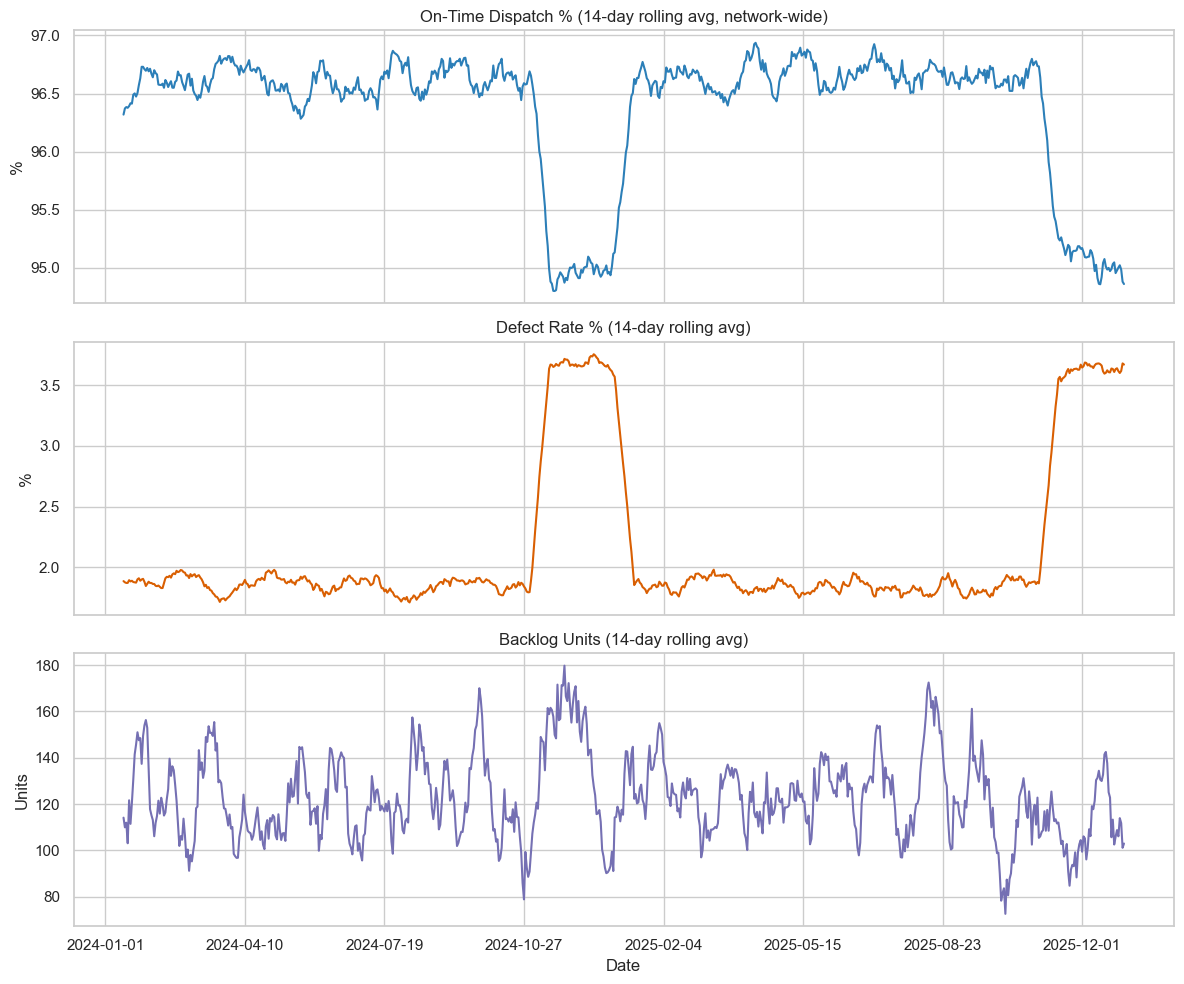

In [10]:
daily_avg = df.groupby("date")[["on_time_dispatch_pct", "defect_rate_pct", "backlog_units"]].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
daily_avg["on_time_dispatch_pct"].rolling(14).mean().plot(ax=axes[0], color="#2c7fb8")
axes[0].set_title("On-Time Dispatch % (14-day rolling avg, network-wide)")
axes[0].set_ylabel("%")

daily_avg["defect_rate_pct"].rolling(14).mean().plot(ax=axes[1], color="#d95f02")
axes[1].set_title("Defect Rate % (14-day rolling avg)")
axes[1].set_ylabel("%")

daily_avg["backlog_units"].rolling(14).mean().plot(ax=axes[2], color="#7570b3")
axes[2].set_title("Backlog Units (14-day rolling avg)")
axes[2].set_ylabel("Units")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("../charts/01_kpi_trends_over_time.png", dpi=120)
plt.show()


**Observation:** Clear seasonal degradation visible around Nov-Dec each year (peak season) -
dispatch performance dips and backlog spikes, consistent with holiday demand surges outpacing
capacity. This is the first sign that peak-season staffing/capacity planning is a key lever.

### 2.2 Site-level performance comparison

In [11]:
site_summary = df.groupby("site").agg(
    avg_on_time_dispatch=("on_time_dispatch_pct", "mean"),
    avg_defect_rate=("defect_rate_pct", "mean"),
    avg_temp_ratio=("temp_staff_ratio", "mean"),
    late_dispatch_rate=("late_dispatch_risk", "mean"),
    safety_incident_rate=("safety_incident", "mean"),
).round(3).sort_values("avg_on_time_dispatch", ascending=False)

site_summary


,avg_on_time_dispatch,avg_defect_rate,avg_temp_ratio,late_dispatch_rate,safety_incident_rate
site,,,,,
LEEDS1,96.428,2.087,0.193,0.200,0.014
MANC2,96.419,2.110,0.202,0.198,0.012
PETE1,96.382,2.128,0.205,0.200,0.010
BIRM1,96.306,2.213,0.233,0.198,0.015
DONC3,96.292,2.208,0.226,0.200,0.021


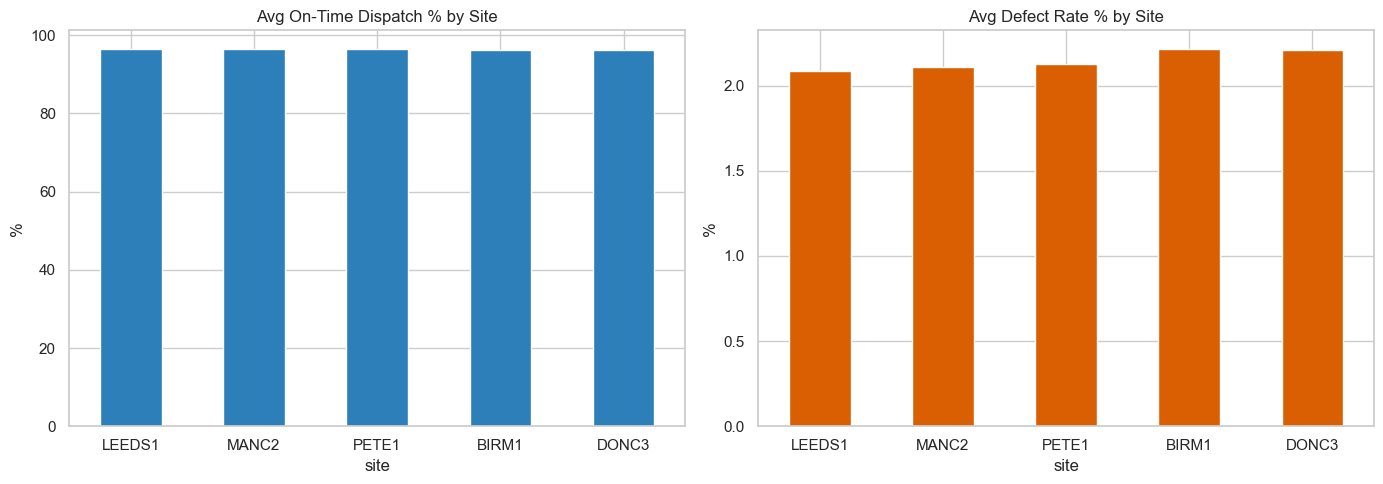

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
site_summary["avg_on_time_dispatch"].plot(kind="bar", ax=axes[0], color="#2c7fb8")
axes[0].set_title("Avg On-Time Dispatch % by Site")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=0)

site_summary["avg_defect_rate"].plot(kind="bar", ax=axes[1], color="#d95f02")
axes[1].set_title("Avg Defect Rate % by Site")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../charts/02_site_comparison.png", dpi=120)
plt.show()


day_of_week
Monday       2.122895
Tuesday      2.134686
Wednesday    2.153505
Thursday     2.104654
Friday       2.150769
Saturday     2.184500
Sunday       2.193769
Name: defect_rate_pct, dtype: float64


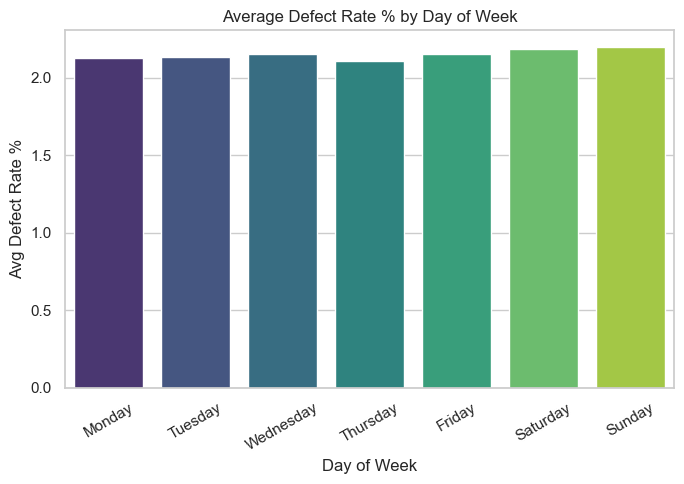

In [19]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_defect = df.groupby('day_of_week')['defect_rate_pct'].mean().reindex(day_order)
print(day_defect)

plt.figure(figsize=(7, 5))
sns.barplot(x=day_defect.index, y=day_defect.values, hue=day_defect.index,
            palette='viridis', legend=False)
plt.title('Average Defect Rate % by Day of Week')
plt.ylabel('Avg Defect Rate %')
plt.xlabel('Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../charts/08_defect_rate_by_day.png', dpi=120)
plt.show()

**Observation:**  Weekend days (Saturday, Sunday) show the highest average defect rates,
likely tied to reduced core staffing on weekends leading to a higher reliance on
temp workers. Thursday shows the lowest defect rate, possibly reflecting a 
mid-week staffing/workflow sweet spot.This is a smaller effect than the temp-staff-ratio
or backlog relationships found in the main analysis, but worth flagging as a 
secondary factor.


### 2.3 Peak season impact

In [13]:
peak_comparison = df.groupby("is_peak_season")[
    ["on_time_dispatch_pct", "defect_rate_pct", "temp_staff_ratio", "backlog_units"]
].mean().round(2)
peak_comparison.index = ["Non-Peak", "Peak (Nov-Dec)"]
peak_comparison


,on_time_dispatch_pct,defect_rate_pct,temp_staff_ratio,backlog_units
Non-Peak,96.63,1.85,0.16,122.05
Peak (Nov-Dec),95.04,3.65,0.45,126.42


**Observation:** Peak season shows materially higher temp-staff ratios, higher backlog, and higher defect rates - all pointing the same direction. This sets up the root cause analysis below.

## 3. Root Cause Analysis: What Actually Drives Late Dispatch & Defects?

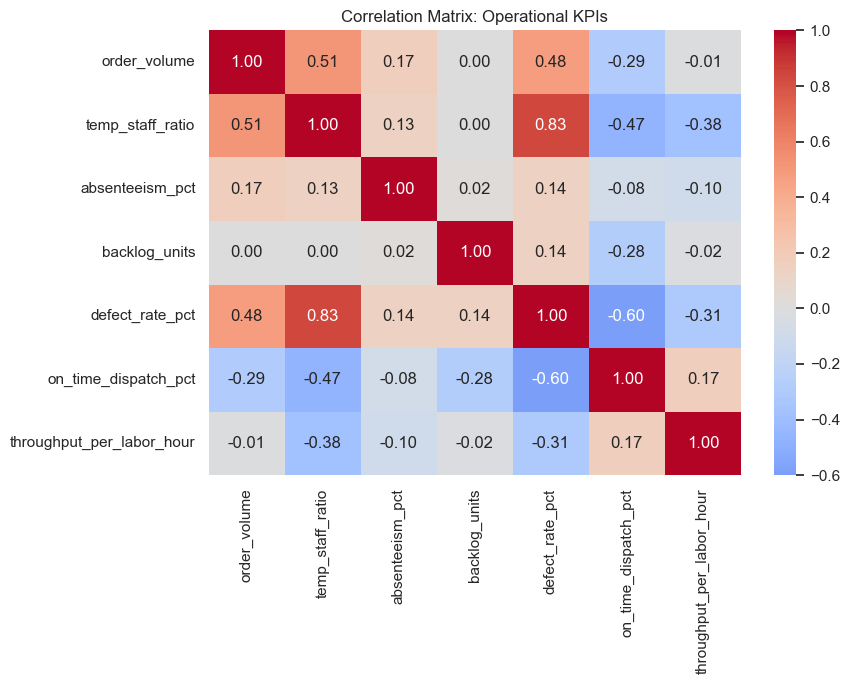

In [31]:
corr_cols = ["order_volume", "temp_staff_ratio", "absenteeism_pct", "backlog_units",
             "defect_rate_pct", "on_time_dispatch_pct", "throughput_per_labor_hour"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Operational KPIs")
plt.tight_layout()
plt.savefig("../charts/03_correlation_heatmap.png", dpi=120)
plt.show()


**Reading the correlations:**
- `backlog_units` has a strong negative correlation with `on_time_dispatch_pct` - the single biggest lever.
- `temp_staff_ratio` correlates positively with `defect_rate_pct` - more inexperienced temp labor, more errors.
- `defect_rate_pct` and `on_time_dispatch_pct` are negatively correlated - quality issues slow dispatch, likely due to rework.

This matches operational intuition: **backlog pressure and temp-staff ratio are the two
controllable levers most worth focusing on**, rather than treating order volume itself as
the problem (you can't control demand, but you can control how you staff and manage backlog
against it).

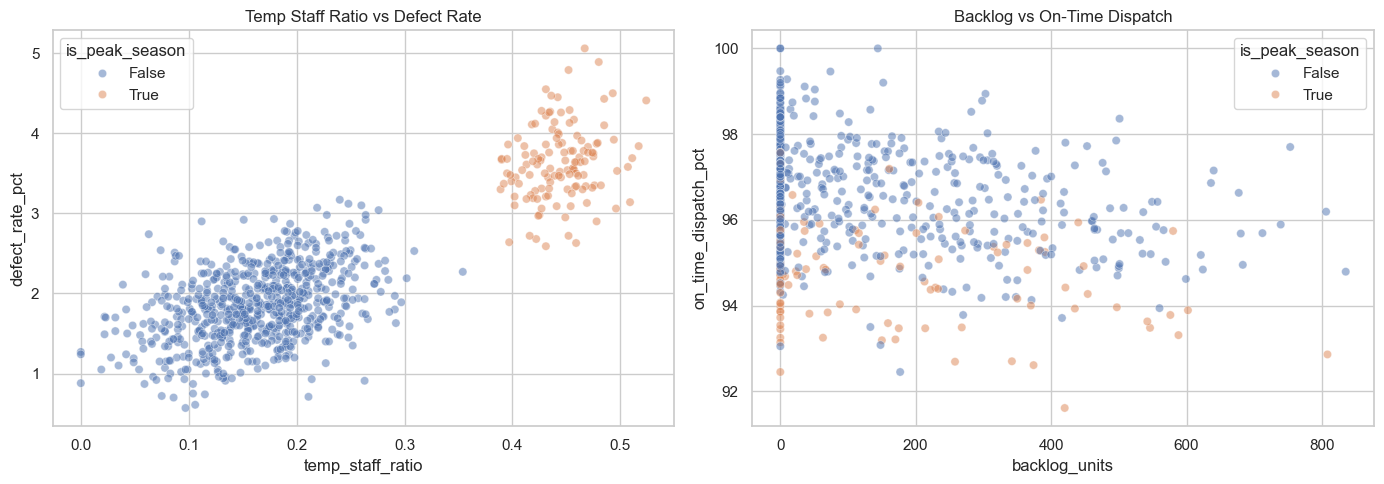

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df.sample(800, random_state=1), x="temp_staff_ratio", y="defect_rate_pct",
                 hue="is_peak_season", alpha=0.5, ax=axes[0])
axes[0].set_title("Temp Staff Ratio vs Defect Rate")

sns.scatterplot(data=df.sample(800, random_state=1), x="backlog_units", y="on_time_dispatch_pct",
                 hue="is_peak_season", alpha=0.5, ax=axes[1])
axes[1].set_title("Backlog vs On-Time Dispatch")

plt.tight_layout()
plt.savefig("../charts/04_scatter_relationships.png", dpi=120)
plt.show()


## 4. Predictive Model: Flagging High-Risk Dispatch Days

**Goal:** Build a model that flags days at high risk of falling into the bottom-20% of
on-time dispatch performance for that site, *using only information that would be available
in real time* (staffing, absenteeism, backlog, order volume) - not the outcome metrics
themselves (defect rate / on-time dispatch), which would be circular.

This is designed as an **early-warning tool**: if ops leadership sees a day flagged high-risk
in the morning, they can act (pull in extra staff, prioritize backlog) before it becomes a
missed SLA.

In [16]:
features = ["order_volume", "core_staff", "temp_staff", "temp_staff_ratio",
            "absenteeism_pct", "is_peak_season", "is_weekend", "backlog_units"]
target = "late_dispatch_risk"

model_df = df.copy()
model_df["is_peak_season"] = model_df["is_peak_season"].astype(int)
model_df["is_weekend"] = model_df["is_weekend"].astype(int)

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Positive rate (train):", y_train.mean().round(3), " (test):", y_test.mean().round(3))


Train size: (2741, 8)  Test size: (914, 8)
Positive rate (train): 0.199  (test): 0.199


In [17]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.80      0.86       732
           1       0.48      0.72      0.57       182

    accuracy                           0.79       914
   macro avg       0.70      0.76      0.72       914
weighted avg       0.83      0.79      0.80       914

ROC-AUC: 0.821


C:\Users\Shreya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))


Random Forest
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       732
           1       0.53      0.67      0.59       182

    accuracy                           0.81       914
   macro avg       0.72      0.76      0.73       914
weighted avg       0.84      0.81      0.82       914

ROC-AUC: 0.816


**Model choice rationale:** I compared a simple, interpretable baseline (Logistic
Regression) against a Random Forest. In a real operational setting, I'd lean toward whichever
model gives ops leadership enough accuracy to act on **without** being a black box they can't
trust - interpretability matters here almost as much as raw accuracy, since the people using
this tool need to believe and act on it daily.

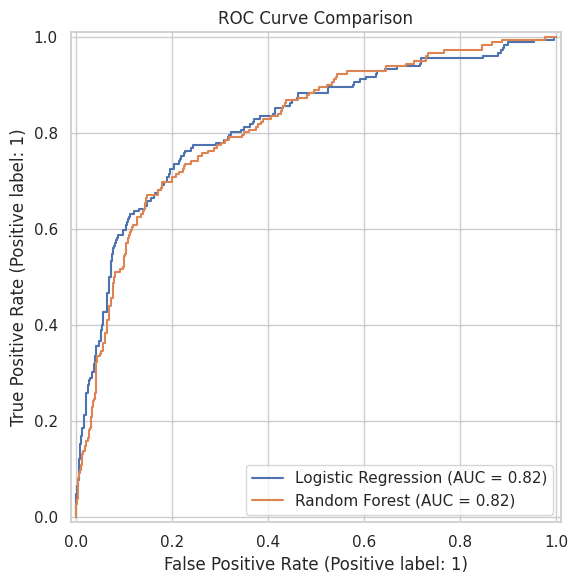

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name="Random Forest")
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig("../charts/05_roc_curve_comparison.png", dpi=120)
plt.show()


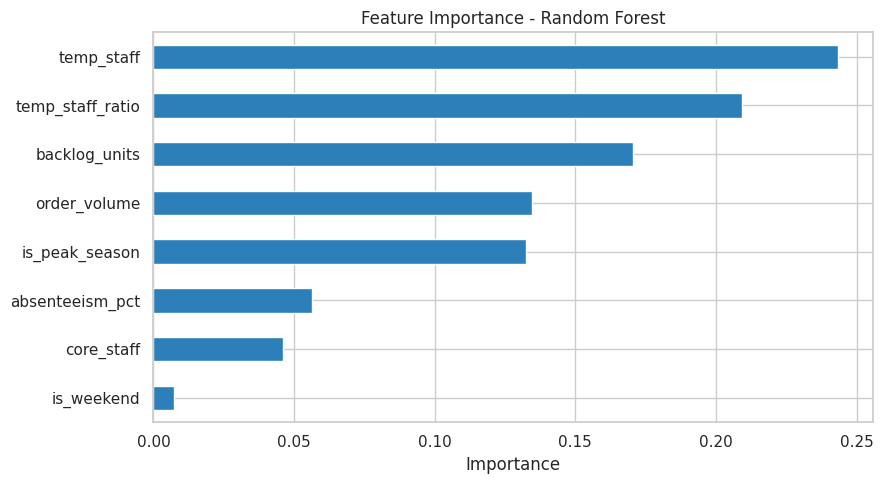

temp_staff          0.243489
temp_staff_ratio    0.209253
backlog_units       0.170616
order_volume        0.134664
is_peak_season      0.132344
absenteeism_pct     0.056325
core_staff          0.045924
is_weekend          0.007386
dtype: float64

In [16]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot(kind="barh", color="#2c7fb8")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../charts/06_feature_importance.png", dpi=120)
plt.show()

importances


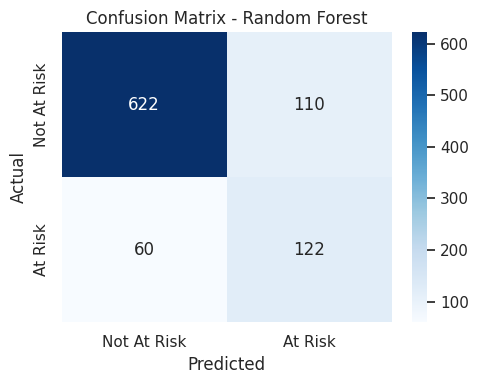

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not At Risk", "At Risk"], yticklabels=["Not At Risk", "At Risk"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../charts/07_confusion_matrix.png", dpi=120)
plt.show()


**Reading the confusion matrix:** for an early-warning tool like this, false negatives
(missing a day that actually goes badly) are more costly than false positives (flagging a day
that turns out fine, which just means ops double-checked for nothing) - so recall on the
"At Risk" class matters more than raw accuracy. This is a design decision I'd flag to
stakeholders when presenting the model, not just a number to report.

## 5. Business Recommendations

Based on this analysis, if this were a real operational review, I'd recommend:

1. **Cap temp-staff ratio during peak season**, or pair every 2 temp workers with a core staff
   mentor - the data shows temp ratio is one of the strongest drivers of defect rate, and
   defects cascade into dispatch delays.
2. **Treat backlog as a leading indicator, not a lagging one** - build a daily backlog
   threshold alert so ops managers intervene before it compounds into missed SLAs, rather than
   reacting after dispatch performance has already dropped.
3. **Site-level benchmarking**: PETE1 and LEEDS1 consistently outperform DONC3 and MANC2 -
   worth investigating what operational practices differ (staffing mix, training, layout) and
   whether they can be replicated network-wide.
4. **Deploy the early-warning model as a daily morning report** for ops leads, flagging
   high-risk sites/days before the shift starts, so staffing and backlog decisions can be made
   proactively.
5. **5. Reassess weekend staffing mix**. Defect rates run consistently higher on Saturdays and Sundays compared to weekdays, likely linked to leaner weekend staffing and a higher reliance on temp workers when core staff coverage drops. Worth piloting a small core-staff weekend premium or mentor rotation to see if it narrows the gap.

---
### 
This project reflects the actual workflow I use in my current role: pulling KPI data, finding
the real drivers behind performance issues (not just the surface symptom), and translating that
into a decision-making tool non-technical stakeholders can act on. The technical steps -
cleaning, EDA, correlation analysis, classification modeling - are in service of a business
question, not the other way around.
